# Spotify Dataset Analysis

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [144]:
df = pd.read_csv('/content/spotify-tracks-dataset.csv')
df

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

# Missing values

In [146]:
df.isnull().sum().sum()

np.int64(3)

In [147]:
df.dropna(inplace=True)

In [148]:
df.drop(
    columns=['Unnamed: 0','Unnamed: 0.1'],
    inplace=True,
    errors='ignore'
)

In [149]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


# Duplicate values

In [150]:
df['track_id'].duplicated().sum()

np.int64(24259)

In [151]:
df[df['track_id'].duplicated(keep=False)] \
    .sort_values('track_id')

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.316000,0.000001,0.1170,0.406,143.064,4,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.316000,0.000001,0.1170,0.406,143.064,4,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.019400,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.019400,0.088100,0.3290,0.700,183.571,1,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.001210,0.000000,0.0995,0.236,148.033,4,rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72679,7zv2vmZq8OjS54BxFzI2wM,Attila,Soundtrack to a Party (Bonus),Lets Start the Party,25,125859,True,0.592,0.932,1,-5.412,1,0.0558,0.000005,0.859000,0.0730,0.677,133.987,4,metalcore
22326,7zv2vmZq8OjS54BxFzI2wM,Attila,Soundtrack to a Party (Bonus),Lets Start the Party,25,125859,True,0.592,0.932,1,-5.412,1,0.0558,0.000005,0.859000,0.0730,0.677,133.987,4,death-metal
2004,7zwn1eykZtZ5LODrf7c0tS,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,You Get Me So High,83,153000,False,0.551,0.881,7,-6.099,0,0.0542,0.186000,0.079100,0.1520,0.387,88.036,4,alt-rock
3100,7zwn1eykZtZ5LODrf7c0tS,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,You Get Me So High,83,153000,False,0.551,0.881,7,-6.099,0,0.0542,0.186000,0.079100,0.1520,0.387,88.036,4,alternative


Some tracks were associated with multiple genres. To support different business questions, two analytical datasets were created:

Song-level dataset (unique tracks)

Genre-level dataset (all genre associations retained)

In [152]:
# Song level
df_song = df.drop_duplicates(subset='track_id')

# Genre level
df_genre = df.copy()

In [153]:
df=pd.read_csv('/content/spotify-tracks-dataset.csv')
df

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [154]:
df_song['track_id'].duplicated().sum()

np.int64(0)

In [155]:
df_song['track_id'].nunique()

89740

# Popularity analysis

How popular are Spotify songs overall?

In [156]:
df_song['popularity'].describe()

,popularity
count,89740.000000
mean,33.198808
std,20.580640
min,0.000000
25%,19.000000
50%,33.000000
75%,49.000000
max,100.000000


The dataset contains 89740 unique tracks with an average popularity score of 33.2. The median popularity is 33, which is close to the mean, which shows a relatively balanced distribution.

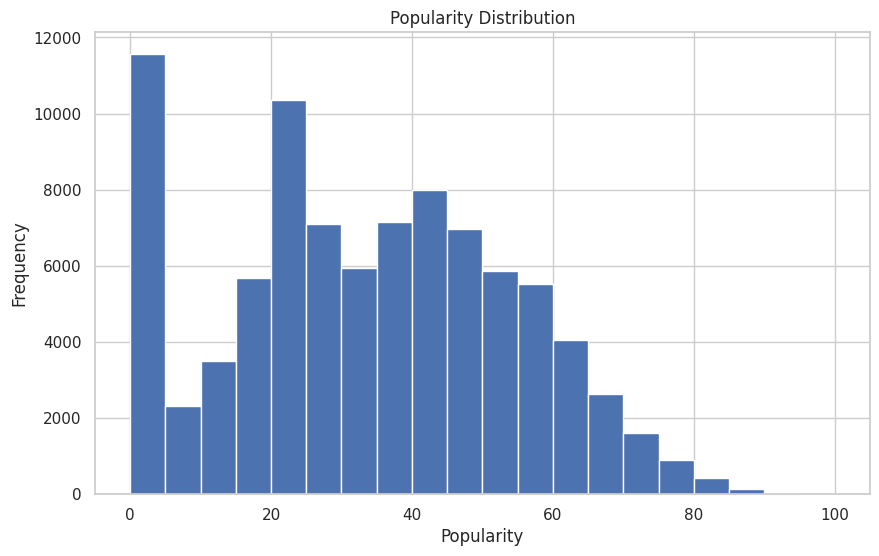

In [157]:
df_song['popularity'].hist(bins=20)
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

What are the top 10 most popular songs?

In [158]:
df_song[['track_name','artists','popularity']].sort_values(by='popularity', ascending=False).head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
67359,Tití Me Preguntó,Bad Bunny,97
79000,I Ain't Worried,OneRepublic,96
20000,Under The Influence,Chris Brown,96
67559,Efecto,Bad Bunny,96
81052,As It Was,Harry Styles,95


What are the top 10 most popular artists?

In [159]:
df_song.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)

,popularity
artists,
Sam Smith;Kim Petras,100.0
Bizarrap;Quevedo,99.0
Manuel Turizo,98.0
Bad Bunny;Chencho Corleone,97.0
Bad Bunny;Bomba Estéreo,95.0
Joji,94.0
Beyoncé,93.0
Rema;Selena Gomez,92.0
Harry Styles,92.0


Which artists are consistently popular rather than having one viral song?

In [160]:
artist_stats = (df_song.groupby('artists')['popularity'].agg(['mean','std','count']))
artist_stats = artist_stats[artist_stats['count'] >= 5]
artist_stats.sort_values('mean', ascending=False)

,mean,std,count
artists,,,
Olivia Rodrigo,87.400000,0.894427,5
Bad Bunny,85.363636,5.341174,22
Lil Nas X,83.200000,5.403702,5
One Direction,83.000000,3.316625,5
Måneskin,82.600000,3.911521,5
...,...,...,...
Azooma,0.000000,0.000000,5
dvsn,0.000000,0.000000,6
MC Lyte,0.000000,0.000000,5


# Genre Analysis

Which genres contain the most tracks?

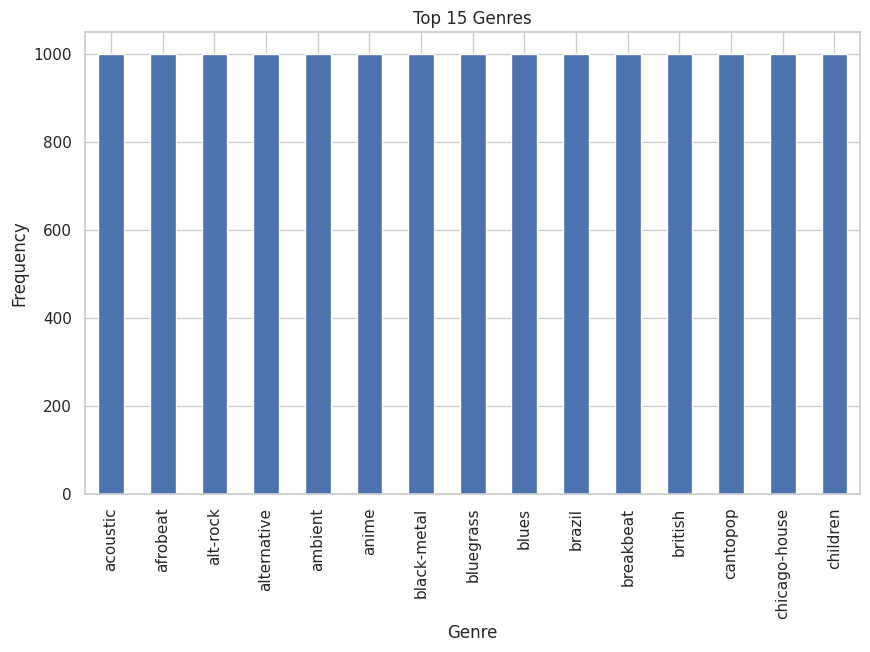

In [161]:
df_genre['track_genre'].value_counts().head(15).plot(kind='bar')
plt.title('Top 15 Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.show()

Which genres are most popular?

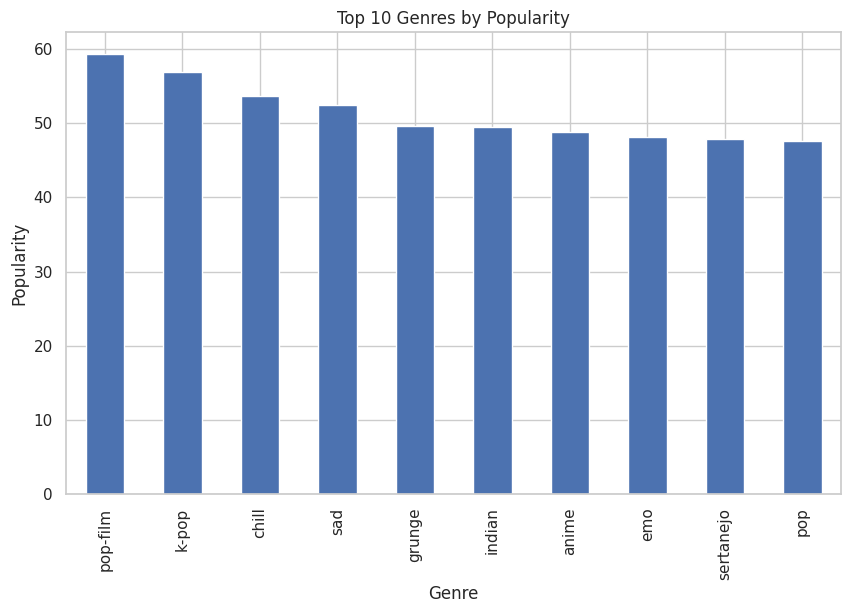

In [162]:
df_genre.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Genres by Popularity')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.show()

Which genres are least popular?

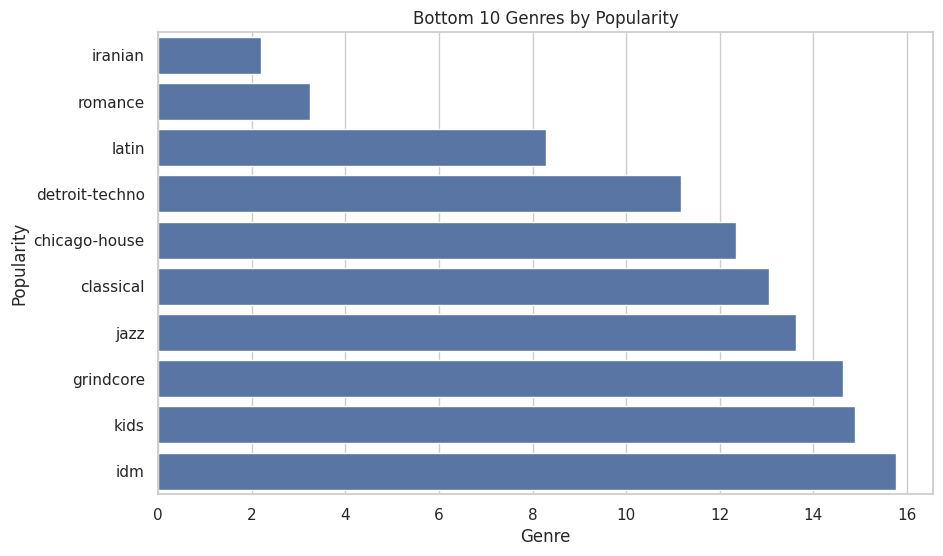

In [163]:
top_genres=df_genre.groupby('track_genre')['popularity'].mean().sort_values().head(10).reset_index()
sns.barplot(
    data=top_genres,
    x='popularity',
    y='track_genre'
)

plt.title('Bottom 10 Genres by Popularity')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.show()

Which genres have the highest danceability?

Text(0, 0.5, 'Danceability')

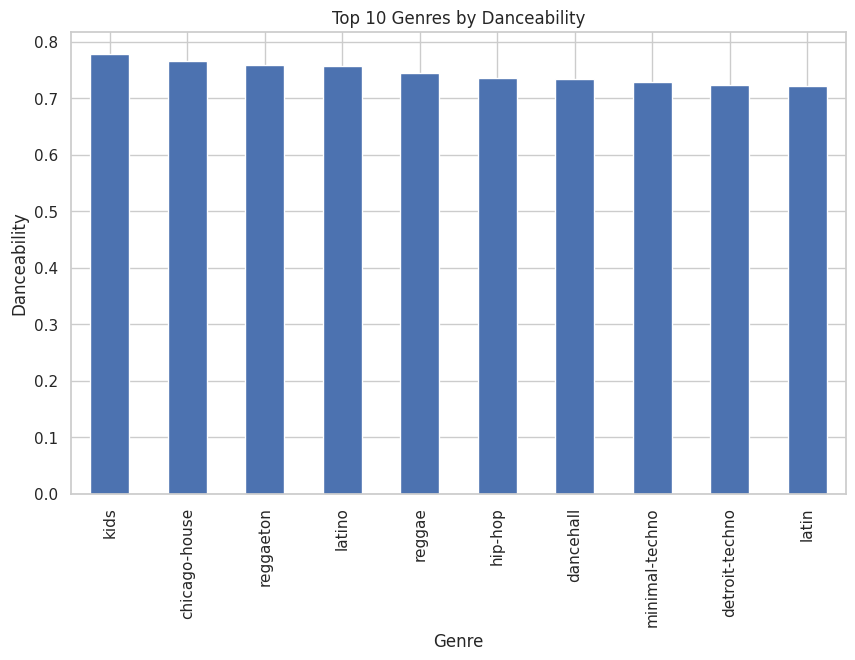

In [164]:
df_genre.groupby('track_genre')['danceability'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Genres by Danceability')
plt.xlabel('Genre')
plt.ylabel('Danceability')

Which genres have the highest energy?

Text(0, 0.5, 'Energy')

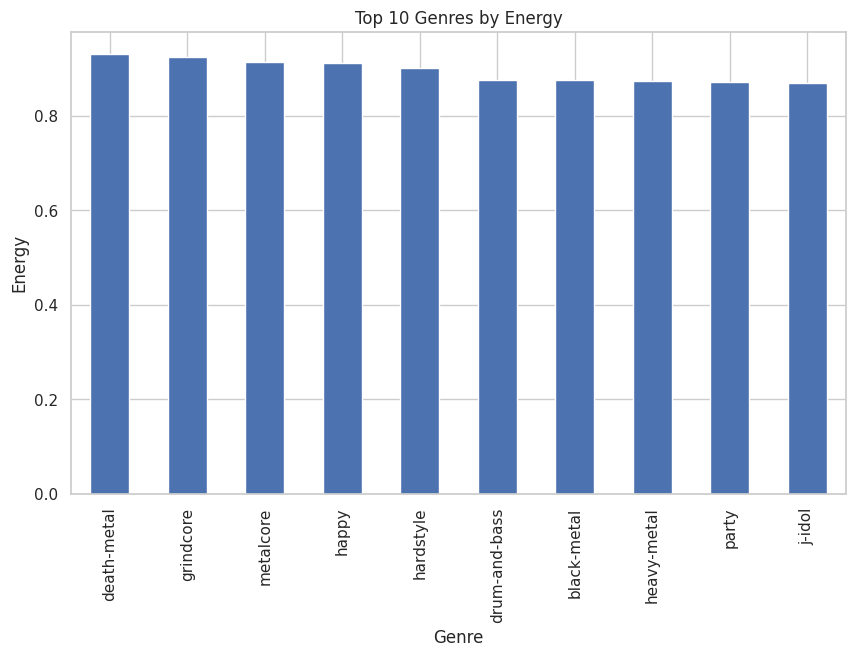

In [165]:
df_genre.groupby('track_genre')['energy'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Genres by Energy')
plt.xlabel('Genre')
plt.ylabel('Energy')

# Audio Features Analysis

What is the average danceability, energy and valence?

In [166]:
df_song[['danceability','energy','valence']].mean()

,0
danceability,0.562166
energy,0.634458
valence,0.469474


Which features are most correlated with popularity?

In [167]:
numeric_cols = df_song.select_dtypes(include='number')

numeric_cols.corr()['popularity'].sort_values(ascending=False)

,popularity
popularity,1.000000
loudness,0.071674
danceability,0.064275
time_signature,0.036898
energy,0.013725
tempo,0.007280
key,0.003441
valence,-0.011508
liveness,-0.013857
mode,-0.016238


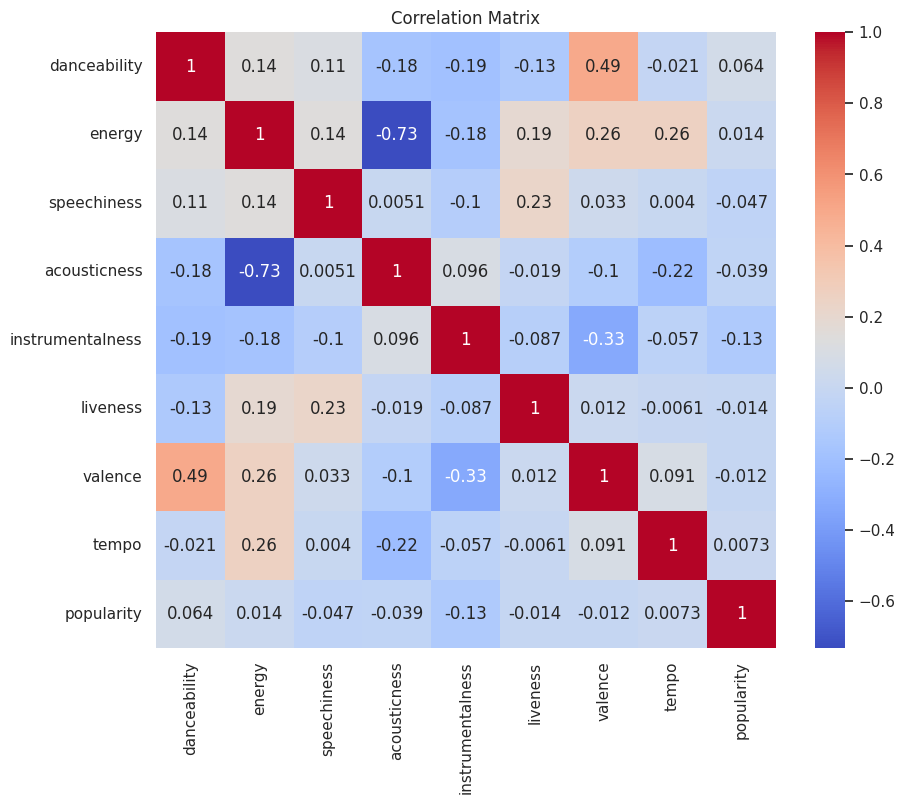

In [168]:
audio_features = [
    'danceability','energy','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo'
]
plt.figure(figsize=(10,8))
corr = df_song[audio_features + ['popularity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


Audio Features Based on Genres

In [169]:
genre_group = df_song.groupby('track_genre')[audio_features].mean()
genre_group.head()


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,
acoustic,0.549593,0.435368,0.043247,0.566816,0.038336,0.153244,0.424023,119.010624
afrobeat,0.669408,0.702938,0.086622,0.270893,0.252876,0.184724,0.698475,119.242057
alt-rock,0.534601,0.754027,0.055076,0.122168,0.054151,0.210340,0.518179,124.654403
alternative,0.595523,0.684523,0.093618,0.185147,0.017173,0.209104,0.476821,119.748902
ambient,0.367966,0.237257,0.041553,0.776701,0.675993,0.129298,0.167345,111.156413


Which songs have excellent audio characteristics but low popularity?

In [170]:
hidden_gems = df_song[
    (df_song['danceability'] > 0.8) &
    (df_song['energy'] > 0.8) &
    (df_song['popularity'] < 20)
]

hidden_gems[['track_name','artists','popularity']]

,track_name,artists,popularity
1348,Can You Get It,Mandrill,7
1510,Rock It,The Dynamics,19
1512,Mandjou,Voilaaa;Lass,19
1564,Cash and Carry - Remix,BANTU;Megaloh;Ghanaian Stallion,19
1616,Let Jesus Row,J Prince,18
...,...,...,...
111679,Call Of The Wild,GusGus,19
111783,Shake Ya Byron,Mo' Horizons,18
111787,Head,Röyksopp,18
111987,La Callejera,Quantic;Anibal Velasquez,18


Do collaborations perform better?

In [171]:
df_song['artist_type'] = df_song['artists'].apply(
    lambda x: 'Collaboration' if ';' in x else 'Solo')

df_song.groupby('artist_type')['popularity'].agg(['mean','median','count'])

/tmp/ipykernel_5769/2711672845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_song['artist_type'] = df_song['artists'].apply(


,mean,median,count
artist_type,,,
Collaboration,34.215355,37.0,22586
Solo,32.856911,32.0,67154


Are collaborations more likely to become hit songs?

In [172]:
threshold = df_song['popularity'].quantile(0.90)

df_song['is_hit'] = df_song['popularity'] >= threshold

df_song.groupby('artist_type')['is_hit'].mean() * 100

/tmp/ipykernel_5769/2894114005.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_song['is_hit'] = df_song['popularity'] >= threshold


,is_hit
artist_type,
Collaboration,12.476756
Solo,10.405933


# Duration Analysis

What is the average song length?

In [173]:
df_song['duration_ms'].mean() / 60000

np.float64(3.8190727596389573)

Which genres have the longest songs?

Text(0, 0.5, 'Average Song Length')

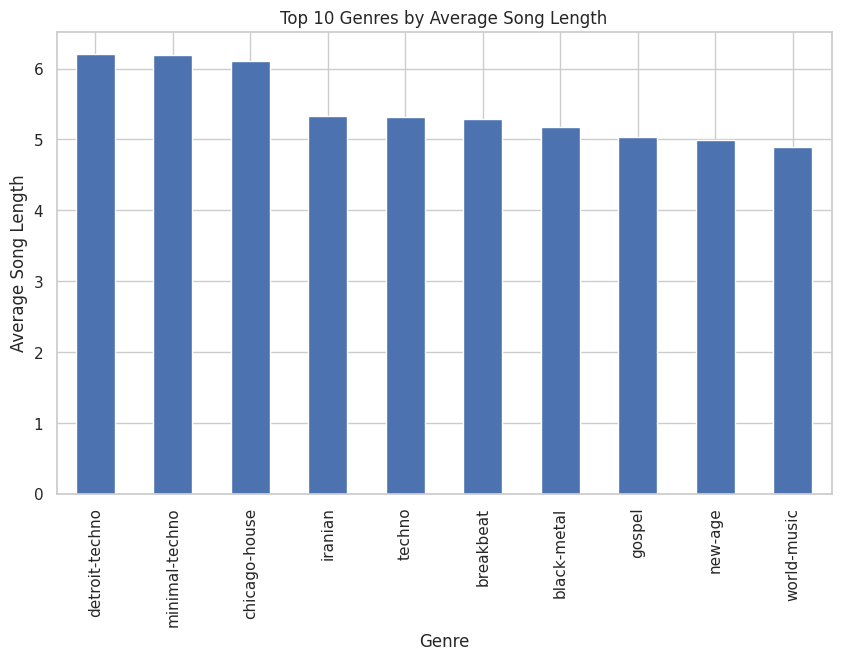

In [174]:
(df_song.groupby('track_genre')['duration_ms'].mean()/60000).sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Genres by Average Song Length')
plt.xlabel('Genre')
plt.ylabel('Average Song Length')

Which genres have the shortest songs?

Text(0, 0.5, 'Average Song Length')

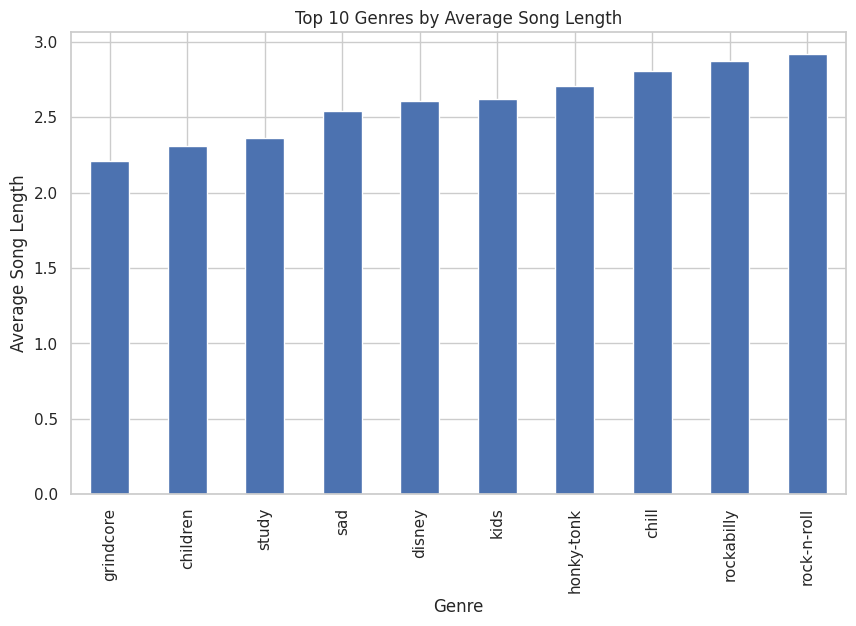

In [175]:
(df_song.groupby('track_genre')['duration_ms'].mean()/60000).sort_values().head(10).plot(kind='bar')
plt.title('Top 10 Genres by Average Song Length')
plt.xlabel('Genre')
plt.ylabel('Average Song Length')

#Song Analysis

What are the characteristics of top 10% songs?

In [176]:
threshold = df_song['popularity'].quantile(0.90)

hits = df_song[df_song['popularity'] >= threshold]

hits[['danceability',
      'energy',
      'valence',
      'acousticness',
      'tempo']].mean()

,0
danceability,0.594551
energy,0.638081
valence,0.484356
acousticness,0.278723
tempo,120.433413


What emotional profile listeners prefer

In [177]:
df_song['song_type'] = 'Other'

df_song.loc[
    (df['energy'] > 0.7) &
    (df['valence'] > 0.7),
    'song_type'
] = 'Happy & Energetic'

df_song.loc[
    (df['energy'] < 0.4) &
    (df['valence'] < 0.4),
    'song_type'
] = 'Sad & Calm'

df_song.groupby('song_type')['popularity'].mean()

/tmp/ipykernel_5769/404642985.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_song['song_type'] = 'Other'


,popularity
song_type,
Happy & Energetic,32.446666
Other,33.673259
Sad & Calm,31.408370


In [178]:
df_song

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,artist_type,is_hit,song_type
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,Solo,True,Other
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,Solo,False,Sad & Calm
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,Collaboration,False,Sad & Calm
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,Solo,True,Sad & Calm
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,Solo,True,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,Solo,False,Sad & Calm
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,Solo,False,Sad & Calm
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,Solo,False,Other
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,Solo,False,Other


# Predict Song Popularity (Regression)


Can Spotify estimate a song's popularity using its audio characteristics before or shortly after release?

In [179]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
features = [
   'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]
x=df_song[features]
y=df_song['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)


model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [180]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 16.608645790291014
MSE: 406.354250467893
R²: 0.02840800369246277


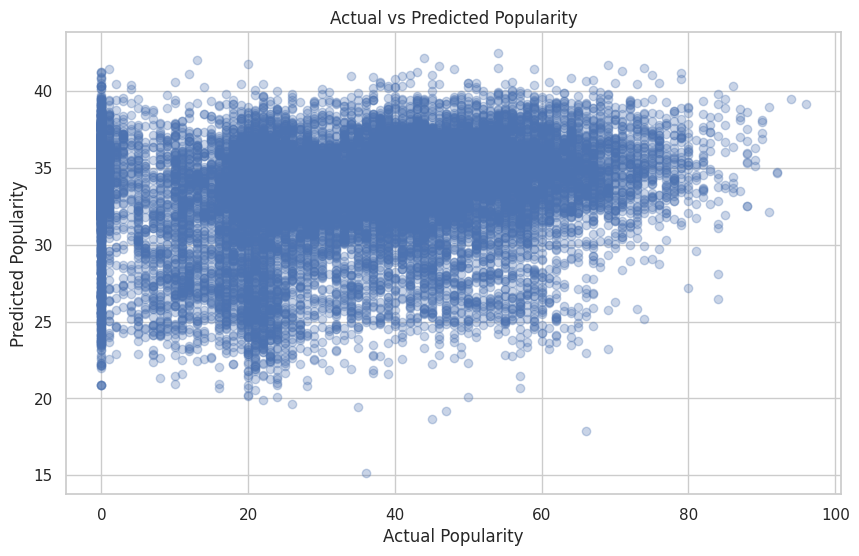

In [181]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")

plt.title("Actual vs Predicted Popularity")

plt.show()